### Cargue los datos en un dataframe

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_wine

# Importar DataFrame
data = load_wine()
df = pd.DataFrame(data['data'])
df.columns = data["feature_names"] 
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


### Identificar el tipo de datos de cada variable.

In [16]:
# Identificar tipos de datos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: float64(13)
m

### Calcular estadísticas básicas para cada variable. Sea de posición, dispersión y tendencia central. Para el caso de variables categóricas, calcule la moda.

In [17]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


### Revisar por cada variable si existen Outliers y cuantificarlos, utilizando los métodos trabajados en la sesión.

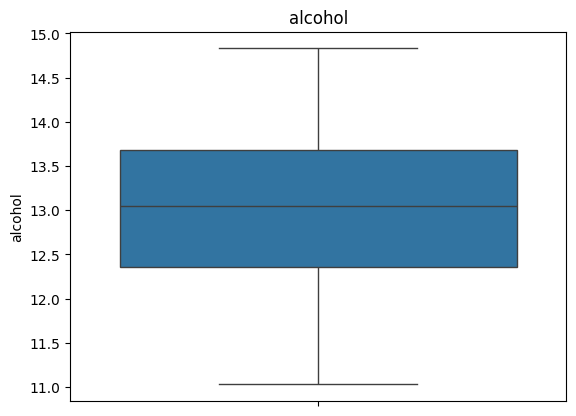

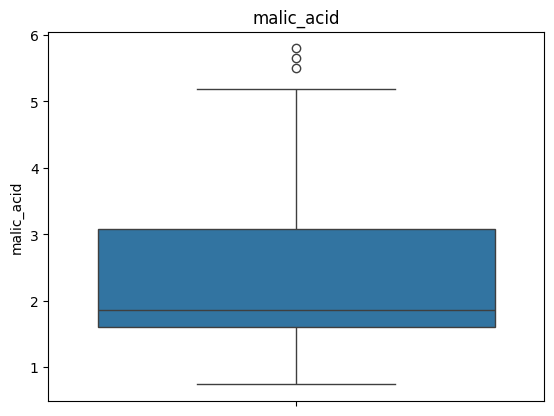

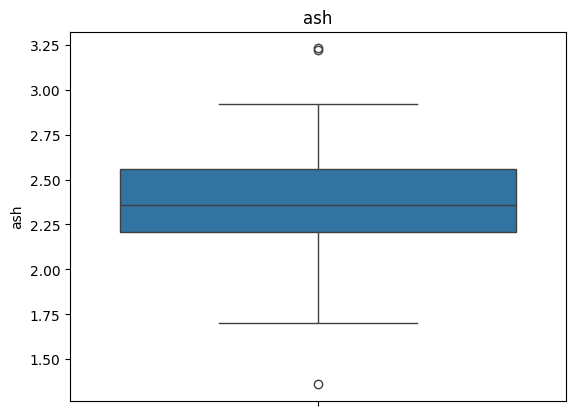

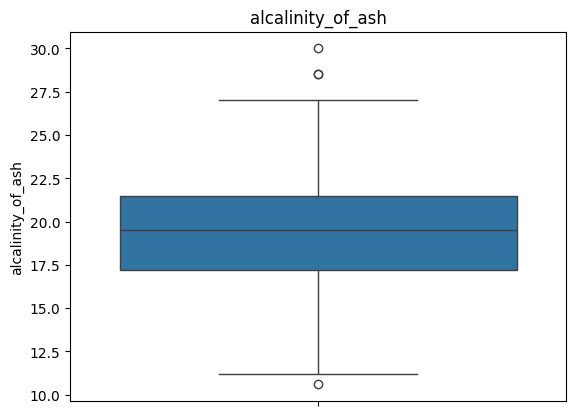

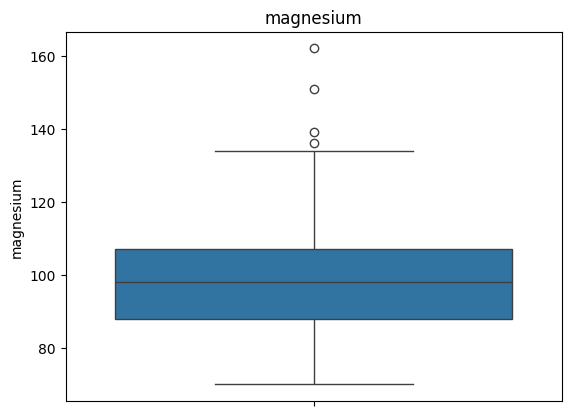

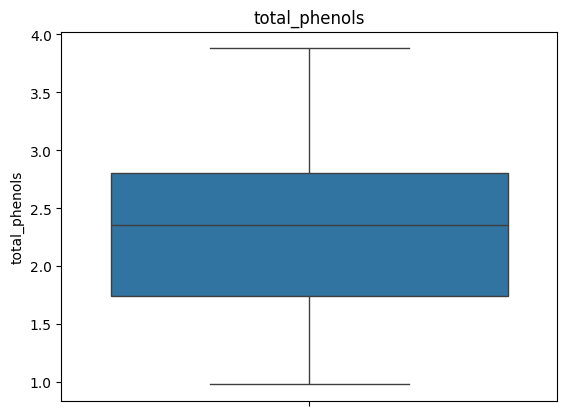

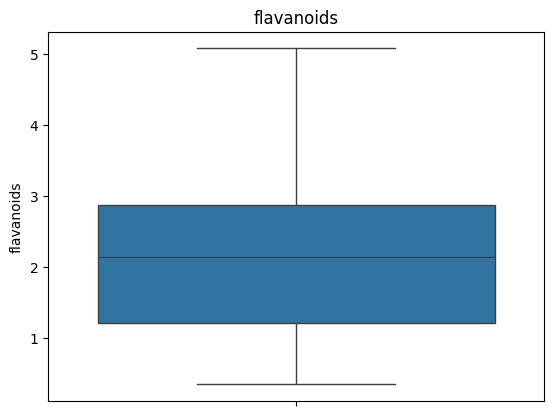

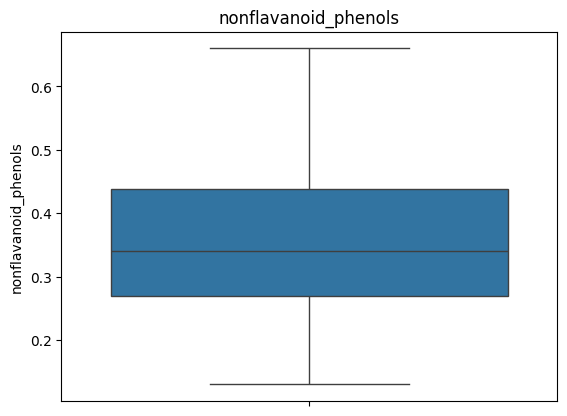

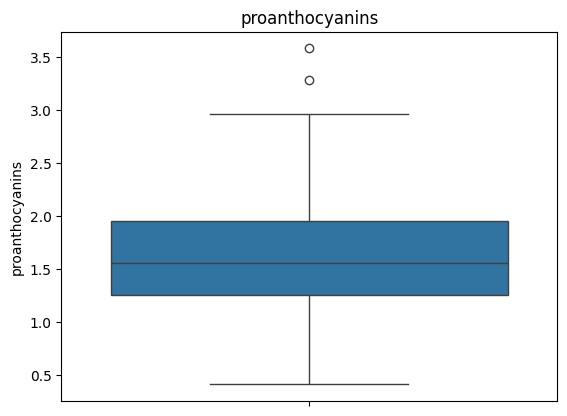

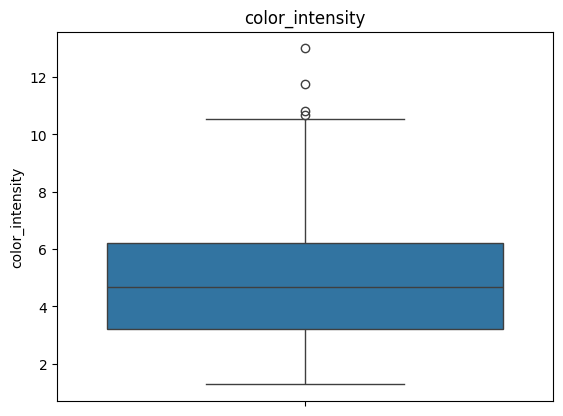

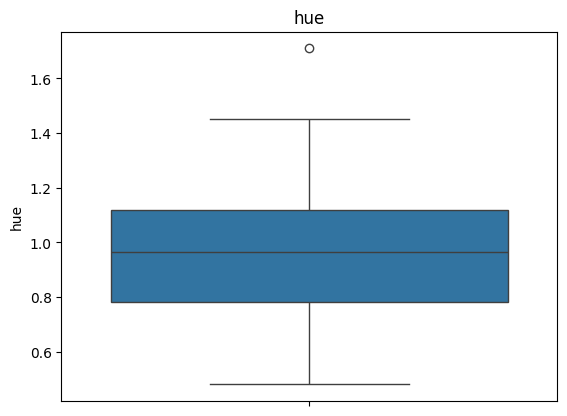

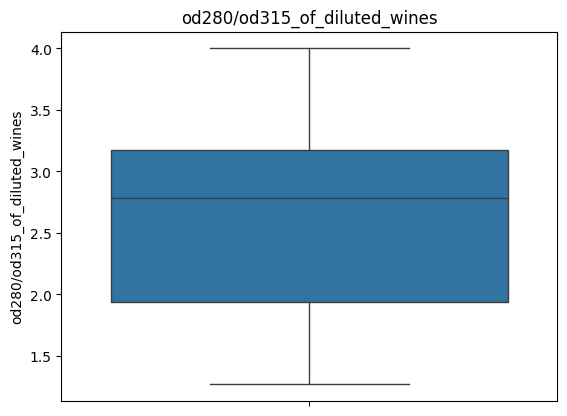

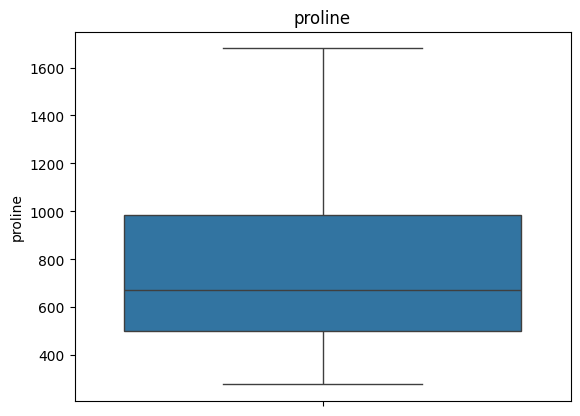

In [18]:
columns = df.columns

# Boxplots
for column in columns:
    sns.boxplot(df[column])
    plt.title(f"{column}")
    plt.show()

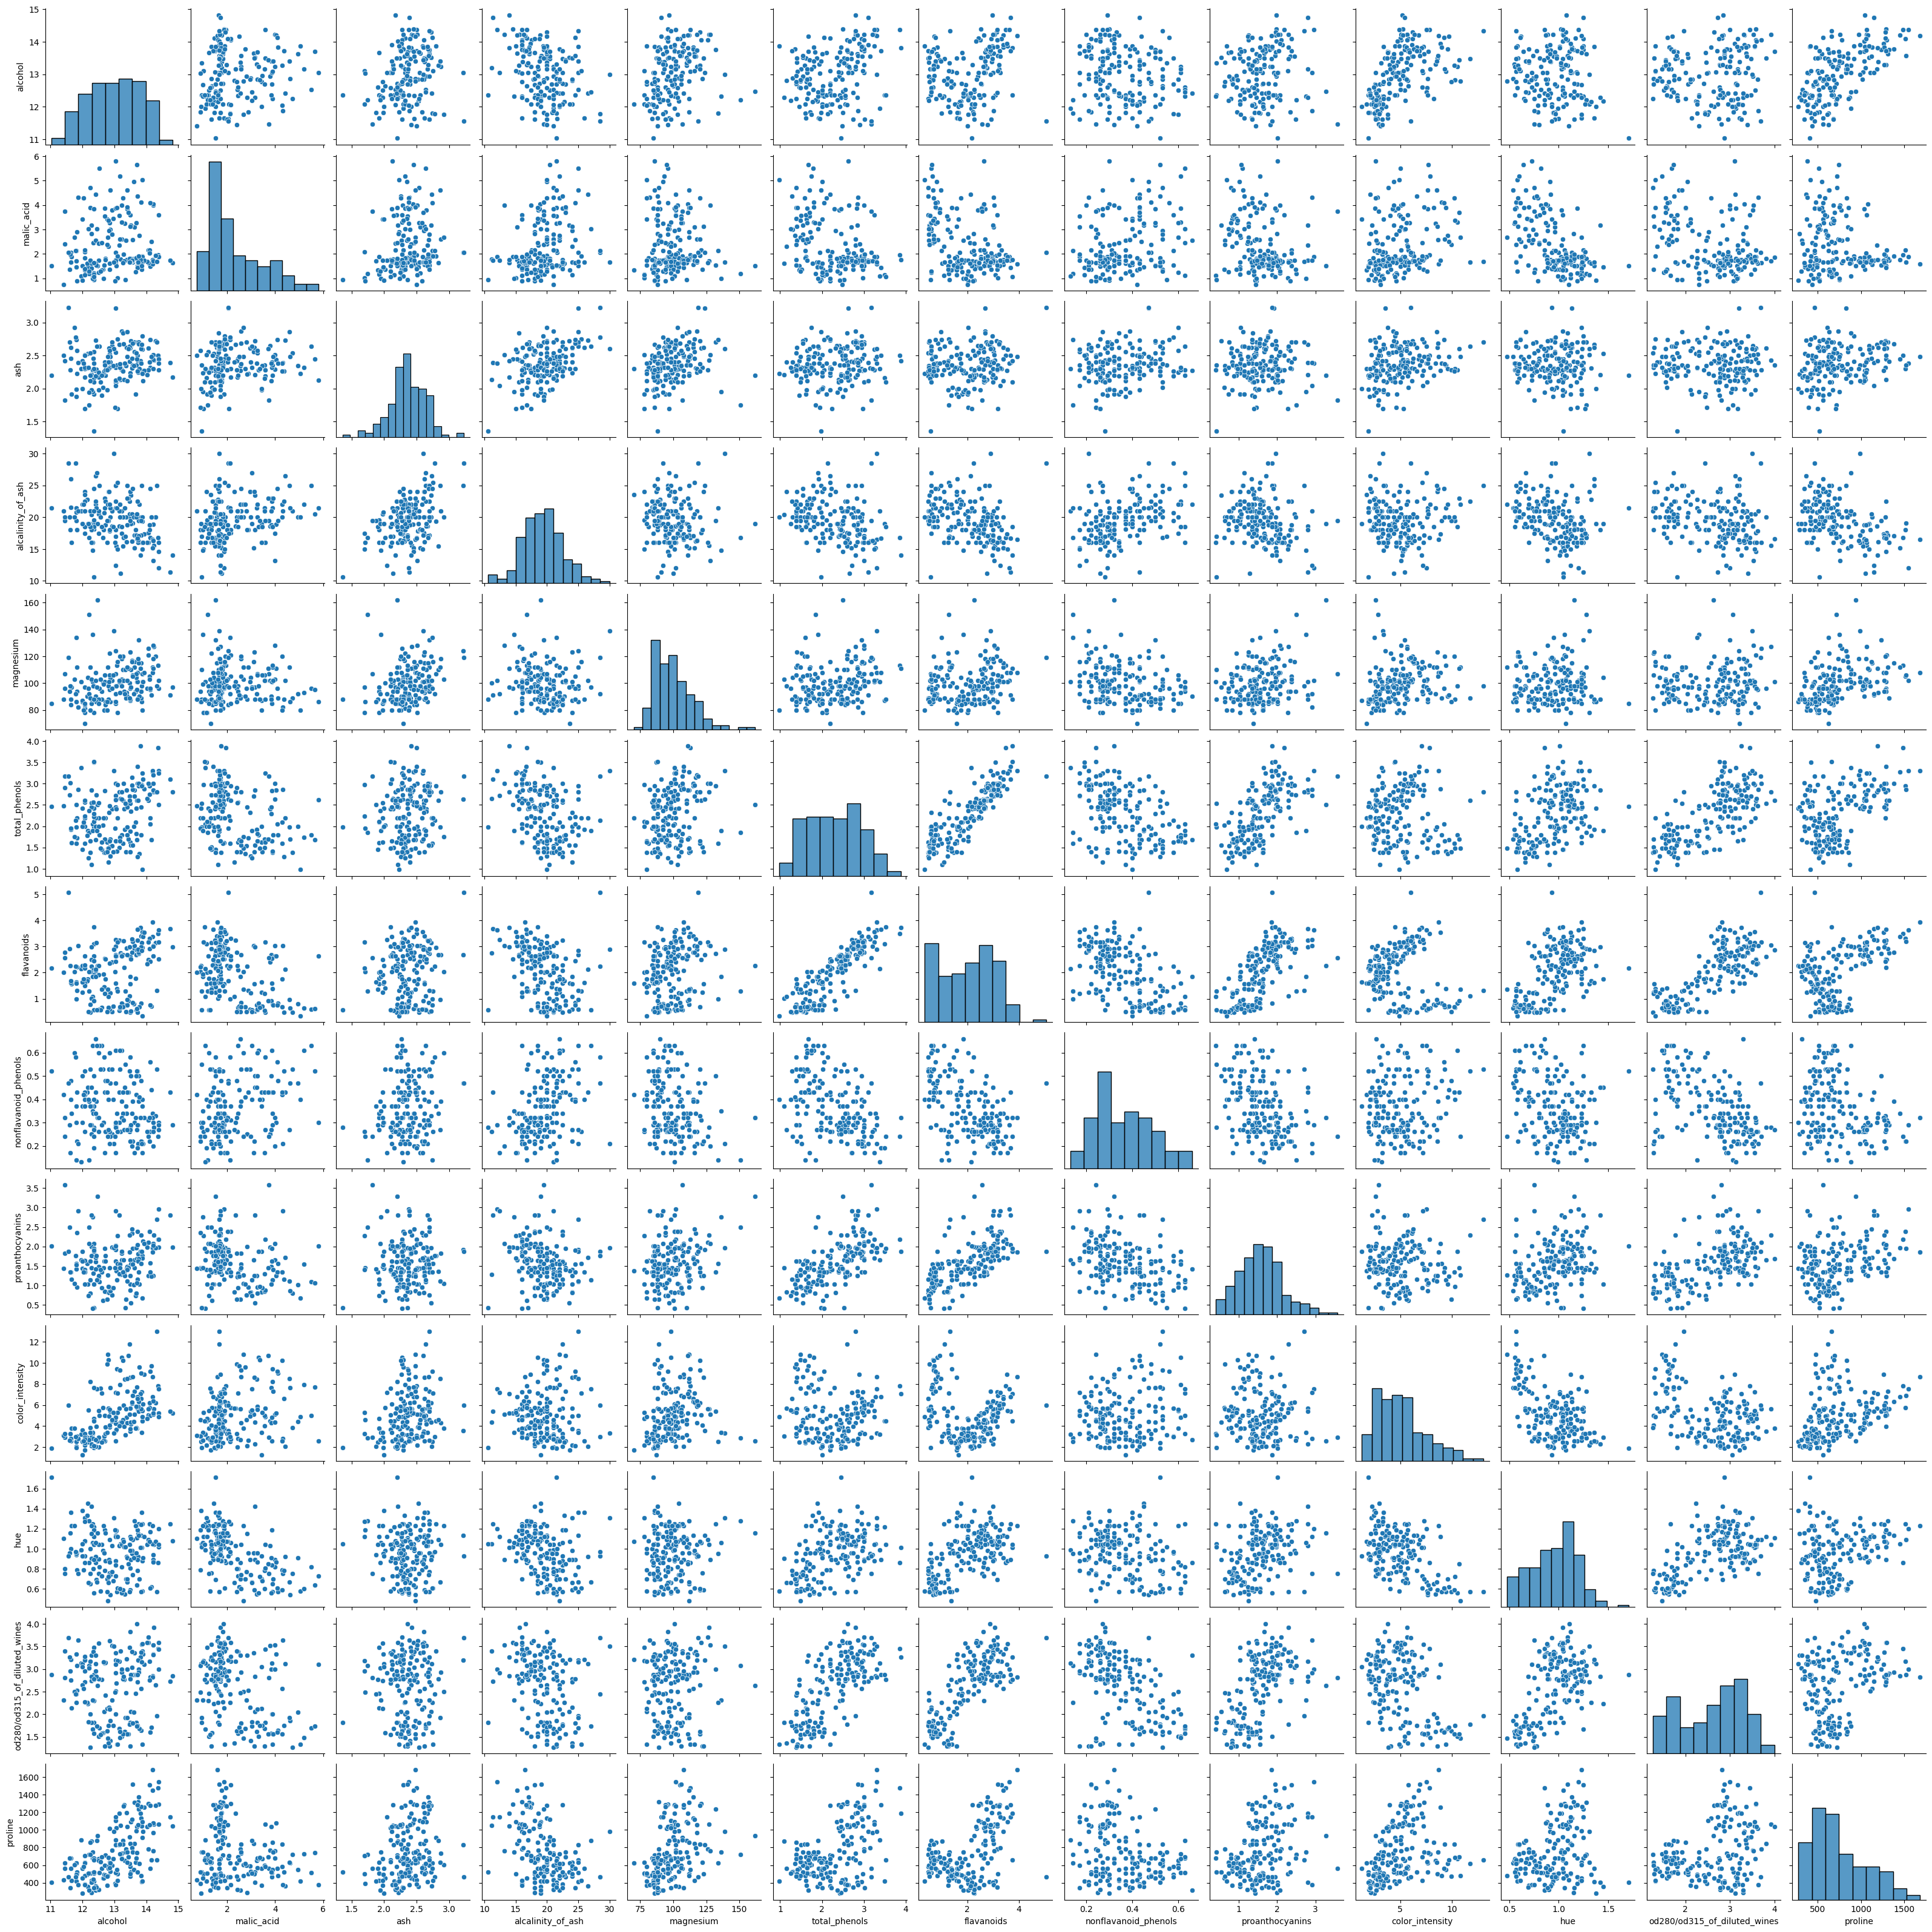

In [19]:
# Scatter plot
sns.pairplot(df)

In [23]:
# ==========================================
# MOSTRAR FILAS CON OUTLIERS SEGÚN IQR
# ==========================================
def detectar_outliers_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = np.round(Q1 - 1.5 * IQR, 2)
    limite_superior = np.round(Q3 + 1.5 * IQR, 2)
    
    mascara = (serie < limite_inferior) | (serie > limite_superior)
    
    return mascara, limite_inferior, limite_superior

mascara_total_iqr = pd.Series(False, index=df.index)
info_limites = {}

for column in columns:
    mascara, li, ls = detectar_outliers_iqr(df[column])
    
    info_limites[column] = {'LI': li, 'LS': ls}
    print("="*30)
    print(f'Límites IQR para {column}:')
    print('Inferior:', li, "| Superior:", ls)
    print(f'Cantidad de outlies en {column}: {mascara.sum()}')
    
    mascara_total_iqr = mascara_total_iqr | mascara

outliers_iqr = df[mascara_total_iqr]
print("Filas detectadas como outliers por IQR:")
display(outliers_iqr)
    

Límites IQR para alcohol:
Inferior: 10.39 | Superior: 15.65
Cantidad de outlies en alcohol: 0
Límites IQR para malic_acid:
Inferior: -0.62 | Superior: 5.3
Cantidad de outlies en malic_acid: 3
Límites IQR para ash:
Inferior: 1.69 | Superior: 3.08
Cantidad de outlies en ash: 3
Límites IQR para alcalinity_of_ash:
Inferior: 10.75 | Superior: 27.95
Cantidad de outlies en alcalinity_of_ash: 4
Límites IQR para magnesium:
Inferior: 59.5 | Superior: 135.5
Cantidad de outlies en magnesium: 4
Límites IQR para total_phenols:
Inferior: 0.16 | Superior: 4.39
Cantidad de outlies en total_phenols: 0
Límites IQR para flavanoids:
Inferior: -1.3 | Superior: 5.38
Cantidad de outlies en flavanoids: 0
Límites IQR para nonflavanoid_phenols:
Inferior: 0.02 | Superior: 0.69
Cantidad de outlies en nonflavanoid_phenols: 0
Límites IQR para proanthocyanins:
Inferior: 0.2 | Superior: 3.0
Cantidad de outlies en proanthocyanins: 2
Límites IQR para color_intensity:
Inferior: -1.25 | Superior: 10.67
Cantidad de outlies

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,LOF_Outlier
25,13.05,2.05,3.22,25.0,124.0,2.63,2.68,0.47,1.92,3.58,1.13,3.20,830.0,1
59,12.37,0.94,1.36,10.6,88.0,1.98,0.57,0.28,0.42,1.95,1.05,1.82,520.0,1
69,12.21,1.19,1.75,16.8,151.0,1.85,1.28,0.14,2.50,2.85,1.28,3.07,718.0,1
73,12.99,1.67,2.60,30.0,139.0,3.30,2.89,0.21,1.96,3.35,1.31,3.50,985.0,1
78,12.33,0.99,1.95,14.8,136.0,1.90,1.85,0.35,2.76,3.40,1.06,2.31,750.0,1
95,12.47,1.52,2.20,19.0,162.0,2.50,2.27,0.32,3.28,2.60,1.16,2.63,937.0,1
110,11.46,3.74,1.82,19.5,107.0,3.18,2.58,0.24,3.58,2.90,0.75,2.81,562.0,1
115,11.03,1.51,2.20,21.5,85.0,2.46,2.17,0.52,2.01,1.90,1.71,2.87,407.0,1
121,11.56,2.05,3.23,28.5,119.0,3.18,5.08,0.47,1.87,6.00,0.93,3.69,465.0,1
123,13.05,5.80,2.13,21.5,86.0,2.62,2.65,0.30,2.01,2.60,0.73,3.10,380.0,1


In [21]:
# ==========================================
# DETECCIÓN CON REGLA DE 3 SIGMAS
# ==========================================

def detectar_outliers_3sigmas(serie):
    media = serie.mean()
    std = serie.std()
    
    limite_inferior = media - 3 * std
    limite_superior = media + 3 *std
    
    mascara = (serie < limite_inferior) | (serie > limite_superior)
    
    return mascara, limite_inferior, limite_superior

mascara_total = pd.Series(False, index=df.index)

for column in columns:
    mascara, li, ls = detectar_outliers_3sigmas(df[column])
    
    print("="*30)
    print(f'Límites 3 sigmas para {column}:')
    print(f'Inferior: {round(li, 2)} | Superior: {round(ls,2)}')
    print(f'Cantidad de outliers en {column}: {mascara.sum()}')
    mascara_total = mascara_total | mascara

Límites 3 sigmas para alcohol:
Inferior: 10.57 | Superior: 15.44
Cantidad de outliers en alcohol: 0
Límites 3 sigmas para malic_acid:
Inferior: -1.02 | Superior: 5.69
Cantidad de outliers en malic_acid: 1
Límites 3 sigmas para ash:
Inferior: 1.54 | Superior: 3.19
Cantidad de outliers en ash: 3
Límites 3 sigmas para alcalinity_of_ash:
Inferior: 9.48 | Superior: 29.51
Cantidad de outliers en alcalinity_of_ash: 1
Límites 3 sigmas para magnesium:
Inferior: 56.89 | Superior: 142.59
Cantidad de outliers en magnesium: 2
Límites 3 sigmas para total_phenols:
Inferior: 0.42 | Superior: 4.17
Cantidad de outliers en total_phenols: 0
Límites 3 sigmas para flavanoids:
Inferior: -0.97 | Superior: 5.03
Cantidad de outliers en flavanoids: 1
Límites 3 sigmas para nonflavanoid_phenols:
Inferior: -0.01 | Superior: 0.74
Cantidad de outliers en nonflavanoid_phenols: 0
Límites 3 sigmas para proanthocyanins:
Inferior: -0.13 | Superior: 3.31
Cantidad de outliers en proanthocyanins: 1
Límites 3 sigmas para colo

In [22]:
# ==========================================
# DETECCIÓN CON LOCAL OUTLIER FACTOR (LOF)
# ==========================================
# LOF evalúa qué tan aislado está un punto respecto a sus vecinos.
from itertools import combinations
from sklearn.neighbors import LocalOutlierFactor

X = df[df.columns]

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
predicciones_lof = lof.fit_predict(X)

# En LOF:
# -1 = outlier
# 1 = normal
df['LOF_Outlier'] = predicciones_lof

print('Cantidad de outliers detectados por LOF', (df['LOF_Outlier'] == -1).sum())
    


Cantidad de outliers detectados por LOF 9


In [29]:
# ==========================================
# IMPACTO DE LOS OUTLIERS EN LAS ESTADÍSTICAS
# ==========================================

df_sin_outliers = df[~mascara_total_iqr].copy()

comparacion = pd.DataFrame({
    "Media original": df[columns].mean(),
    "Media sin outliers": df_sin_outliers[columns].mean(),
    "Mediana original": df[columns].median(),
    "Mediana sin outliers": df_sin_outliers[columns].median(),
    "Desv. estándar original": df[columns].std(),
    "Desv. estándar sin outliers": df_sin_outliers[columns].std()
})

display(comparacion)


,Media original,Media sin outliers,Mediana original,Mediana sin outliers,Desv. estándar original,Desv. estándar sin outliers
alcohol,13.000618,13.040373,13.050,13.07,0.811827,0.797841
malic_acid,2.336348,2.306832,1.865,1.86,1.117146,1.048263
ash,2.366517,2.363292,2.360,2.36,0.274344,0.241205
alcalinity_of_ash,19.494944,19.232298,19.500,19.00,3.339564,3.014706
magnesium,99.741573,98.534161,98.000,98.00,14.282484,12.365290
total_phenols,2.295112,2.290373,2.355,2.35,0.625851,0.632366
flavanoids,2.029270,2.043789,2.135,2.14,0.998859,0.985649
nonflavanoid_phenols,0.361854,0.358137,0.340,0.34,0.124453,0.121810
proanthocyanins,1.590899,1.548075,1.555,1.53,0.572359,0.525859
color_intensity,5.058090,5.014161,4.690,4.80,2.318286,2.117379
